## RAG Pipeline with Chroma DB
Same embedding model (`all-mpnet-base-v2`) + Groq `qwen3-32b`, but using Chroma instead of FAISS.
Chroma supports both **semantic search** and **metadata filtering**.

### 1. Install dependencies

In [1]:
#%pip install -q chromadb langchain-chroma sentence-transformers groq python-dotenv

### 2. Imports

In [3]:
import os
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from groq import Groq

load_dotenv()

/var/folders/z4/qt_tp8rs5gz63c5bp4cryrs00000gn/T/ipykernel_6091/1184307048.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


True

### 3. Define chunks
Each `Document` has:
- `page_content` — plain text (what gets embedded)
- `metadata` — structured fields for filtering (`month`, `year`, `type`)

In [4]:
docs = [
    # [00-01] participants
    Document(
        page_content="Team B participants: Arian, Montassar, Qingshi, Yili, Yuanyuan, Jiacheng.",
        metadata={"type": "info", "month": 0, "year": 0}
    ),
    Document(
        page_content="Supervisors: Paul, Max.",
        metadata={"type": "info", "month": 0, "year": 0}
    ),

    # [02-03] organisation meetings (all teams)
    Document(
        page_content="Shapiq organization meeting #1: date 16.04.2026, time 08:00-10:00, location: Geschw.-Scholl-Pl. 1 (M), M 203, topic: Kick-off, action item: -. Attendees: supervisors, team A,B,C,D,E,F,G,H.",
        metadata={"type": "organization", "month": 4, "year": 2026}
    ),
    Document(
        page_content="Shapiq organization meeting #2: date 23.04.2026, time 09:00-10:30, location: Akademiestr. 7, Room 103/105, topic: Introduction into shapiq and Topic Announcement, action item: -. Attendees: supervisors, team A,B,C,D,E,F,G,H.",
        metadata={"type": "organization", "month": 4, "year": 2026}
    ),

    # [04-09] supervisor meetings (Team B + supervisors)
    Document(
        page_content="Shapiq supervisor meeting #1: date 06.05.2026, time 09:15-10:00, location: Akademiestr. 7, Room 103/105, topic: group meeting, action item: meeting slides. Attendees: Team B + supervisors.",
        metadata={"type": "supervisor", "month": 5, "year": 2026}
    ),
    Document(
        page_content="Shapiq supervisor meeting #2: date 20.05.2026, time 09:15-10:00, location: Akademiestr. 7, Room 103/105, topic: group meeting, action item: meeting slides. Attendees: Team B + supervisors.",
        metadata={"type": "supervisor", "month": 5, "year": 2026}
    ),
    Document(
        page_content="Shapiq supervisor meeting #3: date 03.06.2026, time 09:15-10:00, location: Akademiestr. 7, Room 103/105, topic: group meeting, action item: meeting slides. Attendees: Team B + supervisors.",
        metadata={"type": "supervisor", "month": 6, "year": 2026}
    ),
    Document(
        page_content="Shapiq supervisor meeting #4: date 17.06.2026, time 09:15-10:00, location: zoom, topic: group meeting, action item: meeting slides. Attendees: Team B + supervisors.",
        metadata={"type": "supervisor", "month": 6, "year": 2026}
    ),
    Document(
        page_content="Shapiq supervisor meeting #5: date 01.07.2026, time 09:15-10:00, location: Akademiestr. 7, Room 103/105, topic: group meeting, action item: meeting slides. Attendees: Team B + supervisors.",
        metadata={"type": "supervisor", "month": 7, "year": 2026}
    ),
    Document(
        page_content="Shapiq supervisor meeting #6: date 15.07.2026, time 09:15-10:00, location: Akademiestr. 7, Room 103/105, topic: group meeting, action item: meeting slides. Attendees: Team B + supervisors.",
        metadata={"type": "supervisor", "month": 7, "year": 2026}
    ),

    # [10-19] internal update meetings (Team B only, Sundays)
    Document(
        page_content="Shapiq internal meeting: date 10.05.2026 (Sunday), topic: internal update, discuss next steps, task distribution, action item: -. Attendees: Team B.",
        metadata={"type": "internal", "month": 5, "year": 2026}
    ),
    Document(
        page_content="Shapiq internal meeting: date 17.05.2026 (Sunday), topic: internal update, discuss next steps, task distribution, action item: -. Attendees: Team B.",
        metadata={"type": "internal", "month": 5, "year": 2026}
    ),
    Document(
        page_content="Shapiq internal meeting: date 24.05.2026 (Sunday), topic: internal update, discuss next steps, task distribution, action item: -. Attendees: Team B.",
        metadata={"type": "internal", "month": 5, "year": 2026}
    ),
    Document(
        page_content="Shapiq internal meeting: date 31.05.2026 (Sunday), topic: internal update, discuss next steps, task distribution, action item: -. Attendees: Team B.",
        metadata={"type": "internal", "month": 5, "year": 2026}
    ),
    Document(
        page_content="Shapiq internal meeting: date 07.06.2026 (Sunday), topic: internal update, discuss next steps, task distribution, action item: -. Attendees: Team B.",
        metadata={"type": "internal", "month": 6, "year": 2026}
    ),
    Document(
        page_content="Shapiq internal meeting: date 14.06.2026 (Sunday), topic: internal update, discuss next steps, task distribution, action item: -. Attendees: Team B.",
        metadata={"type": "internal", "month": 6, "year": 2026}
    ),
    Document(
        page_content="Shapiq internal meeting: date 21.06.2026 (Sunday), topic: internal update, discuss next steps, task distribution, action item: -. Attendees: Team B.",
        metadata={"type": "internal", "month": 6, "year": 2026}
    ),
    Document(
        page_content="Shapiq internal meeting: date 28.06.2026 (Sunday), topic: internal update, discuss next steps, task distribution, action item: -. Attendees: Team B.",
        metadata={"type": "internal", "month": 6, "year": 2026}
    ),
    Document(
        page_content="Shapiq internal meeting: date 05.07.2026 (Sunday), topic: internal update, discuss next steps, task distribution, action item: -. Attendees: Team B.",
        metadata={"type": "internal", "month": 7, "year": 2026}
    ),
    Document(
        page_content="Shapiq internal meeting: date 12.07.2026 (Sunday), topic: internal update, discuss next steps, task distribution, action item: -. Attendees: Team B.",
        metadata={"type": "internal", "month": 7, "year": 2026}
    ),

    # [20-25] slides preparation meetings (Team B only)
    Document(
        page_content="Shapiq slides preparation meeting: date 05.05.2026, topic: prepare supervisor meeting, action item: prepare meeting slides. Attendees: Team B.",
        metadata={"type": "preparation", "month": 5, "year": 2026}
    ),
    Document(
        page_content="Shapiq slides preparation meeting: date 19.05.2026, topic: prepare supervisor meeting, action item: prepare meeting slides. Attendees: Team B.",
        metadata={"type": "preparation", "month": 5, "year": 2026}
    ),
    Document(
        page_content="Shapiq slides preparation meeting: date 02.06.2026, topic: prepare supervisor meeting, action item: prepare meeting slides. Attendees: Team B.",
        metadata={"type": "preparation", "month": 6, "year": 2026}
    ),
    Document(
        page_content="Shapiq slides preparation meeting: date 16.06.2026, topic: prepare supervisor meeting, action item: prepare meeting slides. Attendees: Team B.",
        metadata={"type": "preparation", "month": 6, "year": 2026}
    ),
    Document(
        page_content="Shapiq slides preparation meeting: date 30.06.2026, topic: prepare supervisor meeting, action item: prepare meeting slides. Attendees: Team B.",
        metadata={"type": "preparation", "month": 6, "year": 2026}
    ),
    Document(
        page_content="Shapiq slides preparation meeting: date 14.07.2026, topic: prepare supervisor meeting, action item: prepare meeting slides. Attendees: Team B.",
        metadata={"type": "preparation", "month": 7, "year": 2026}
    ),

    # [26] submission
    Document(
        page_content="Shapiq final submission: date 17.07.2026, topic: final submission, action item: PR/Demo.",
        metadata={"type": "submission", "month": 7, "year": 2026}
    ),
]

print(f"Total documents: {len(docs)}")
for i, d in enumerate(docs):
    print(f"[{i:02d}] {d.metadata} | {d.page_content[:80]}...")

Total documents: 27
[00] {'type': 'info', 'month': 0, 'year': 0} | Team B participants: Arian, Montassar, Qingshi, Yili, Yuanyuan, Jiacheng....
[01] {'type': 'info', 'month': 0, 'year': 0} | Supervisors: Paul, Max....
[02] {'type': 'organization', 'month': 4, 'year': 2026} | Shapiq organization meeting #1: date 16.04.2026, time 08:00-10:00, location: Ges...
[03] {'type': 'organization', 'month': 4, 'year': 2026} | Shapiq organization meeting #2: date 23.04.2026, time 09:00-10:30, location: Aka...
[04] {'type': 'supervisor', 'month': 5, 'year': 2026} | Shapiq supervisor meeting #1: date 06.05.2026, time 09:15-10:00, location: Akade...
[05] {'type': 'supervisor', 'month': 5, 'year': 2026} | Shapiq supervisor meeting #2: date 20.05.2026, time 09:15-10:00, location: Akade...
[06] {'type': 'supervisor', 'month': 6, 'year': 2026} | Shapiq supervisor meeting #3: date 03.06.2026, time 09:15-10:00, location: Akade...
[07] {'type': 'supervisor', 'month': 6, 'year': 2026} | Shapiq supervisor meet

### 4. Embed & store in Chroma
Chroma persists to disk at `./chroma_shapiq/` — you'll see the folder after running this cell.

In [5]:
DB_PATH = "./chroma_shapiq"

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2",
    encode_kwargs={"normalize_embeddings": True},
)

db = Chroma.from_documents(
    documents=docs,
    embedding=embedding_model,
    persist_directory=DB_PATH,
)

print(f"Chroma DB saved to '{DB_PATH}/'")
print(f"Total vectors stored: {db._collection.count()}")

/var/folders/z4/qt_tp8rs5gz63c5bp4cryrs00000gn/T/ipykernel_6091/4159450858.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Chroma DB saved to './chroma_shapiq/'
Total vectors stored: 27


### 5. Reload DB (optional)
Skip if running end-to-end. Use this to load the persisted DB without re-embedding.

In [6]:
db = Chroma(
     persist_directory=DB_PATH,
     embedding_function=embedding_model,
 )
print(f"Loaded {db._collection.count()} vectors.")

Loaded 27 vectors.


### 6. Retrieve — semantic search + metadata filter
The `where` filter runs **before** semantic search — only May 2026 documents are candidates.

Remove or adjust `where` for pure semantic search.

In [9]:
USER_QUERY = "Shapiq meetings Team B May 2026"

# --- Option A: semantic search only (no filter) ---
# results = db.similarity_search_with_score(USER_QUERY, k=10)

# --- Option B: metadata filter first, then semantic search (recommended) ---
results = db.similarity_search_with_score(
    USER_QUERY,
    k=10,
    filter={"month": 5},        # only May documents
)

print(f"Query: {USER_QUERY}\n")
print("── Retrieved chunks ──")
retrieved_chunks = []
for rank, (doc, score) in enumerate(results, 1):
    print(f"[{rank}] score={score:.4f} | {doc.metadata}")
    print(f"    {doc.page_content[:110]}...\n")
    retrieved_chunks.append(doc.page_content)

Query: Shapiq meetings Team B May 2026

── Retrieved chunks ──
[1] score=0.6376 | {'type': 'internal', 'month': 5, 'year': 2026}
    Shapiq internal meeting: date 24.05.2026 (Sunday), topic: internal update, discuss next steps, task distributi...

[2] score=0.6535 | {'month': 5, 'year': 2026, 'type': 'internal'}
    Shapiq internal meeting: date 31.05.2026 (Sunday), topic: internal update, discuss next steps, task distributi...

[3] score=0.6563 | {'type': 'internal', 'year': 2026, 'month': 5}
    Shapiq internal meeting: date 17.05.2026 (Sunday), topic: internal update, discuss next steps, task distributi...

[4] score=0.6630 | {'type': 'internal', 'month': 5, 'year': 2026}
    Shapiq internal meeting: date 10.05.2026 (Sunday), topic: internal update, discuss next steps, task distributi...

[5] score=0.8464 | {'month': 5, 'year': 2026, 'type': 'supervisor'}
    Shapiq supervisor meeting #1: date 06.05.2026, time 09:15-10:00, location: Akademiestr. 7, Room 103/105, topic...

[6] score=

### 7. Generate answer with Groq (qwen3-32b)

In [10]:
context = "\n\n".join(f"[{i+1}] {c}" for i, c in enumerate(retrieved_chunks))

system_prompt = (
    "You are a helpful assistant for a university practical course called Shapiq. "
    "Answer the user's question using ONLY the provided context chunks. "
    "Cite the chunk numbers you use. Be concise and precise."
)

client = Groq(api_key=os.environ["GROQ_API_KEY"])

response = client.chat.completions.create(
    model="qwen/qwen3-32b",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": f"Context:\n{context}\n\nQuestion: {USER_QUERY}"},
    ],
    temperature=0.0,
)

print("── LLM Answer ──")
print(response.choices[0].message.content)

── LLM Answer ──
<think>
Okay, the user is asking about Shapiq meetings for Team B in May 2026. Let me look through the provided context chunks to find all relevant meetings.

First, I'll list out each chunk and check the dates and details. 

Chunk 1: May 24, 2026 (Sunday) - internal update meeting. Attendees: Team B. Topics include discussing next steps and task distribution. No action item mentioned.

Chunk 2: May 31, 2026 (Sunday) - another internal meeting with the same topics. Team B attends.

Chunk 3: May 17, 2026 (Sunday) - internal meeting again. Same structure as the others. Team B is there.

Chunk 4: May 10, 2026 (Sunday) - internal meeting. Team B attends. Topics are consistent.

Chunk 5: Supervisor meeting #1 on May 6, 2026 at 9:15-10:00 AM in Room 103/105 at Akademiestr. 7. Attendees are Team B plus supervisors. Action item is meeting slides.

Chunk 6: Supervisor meeting #2 on May 20, 2026, same time and location as #1. Attendees same. Action item slides again.

Chunk 7: S

# Pipeline Summary:

* write the data (as json/plaintext/langchain_document/csv) that has metadata and content
* (optionally, split into specific chunksize if too large)
* embed into db (chroma/faiss/etc.) with `all-mpnet-base-v2"

* given user query
* user query is embedded with `all-mpnet-base-v2"
* retrieve the topK db chunks that have the highest similarity score with the embedded user query (metadata filtering/semantic search(cosine similarity))
* feed all retrieved chunks to the LLM for inference.


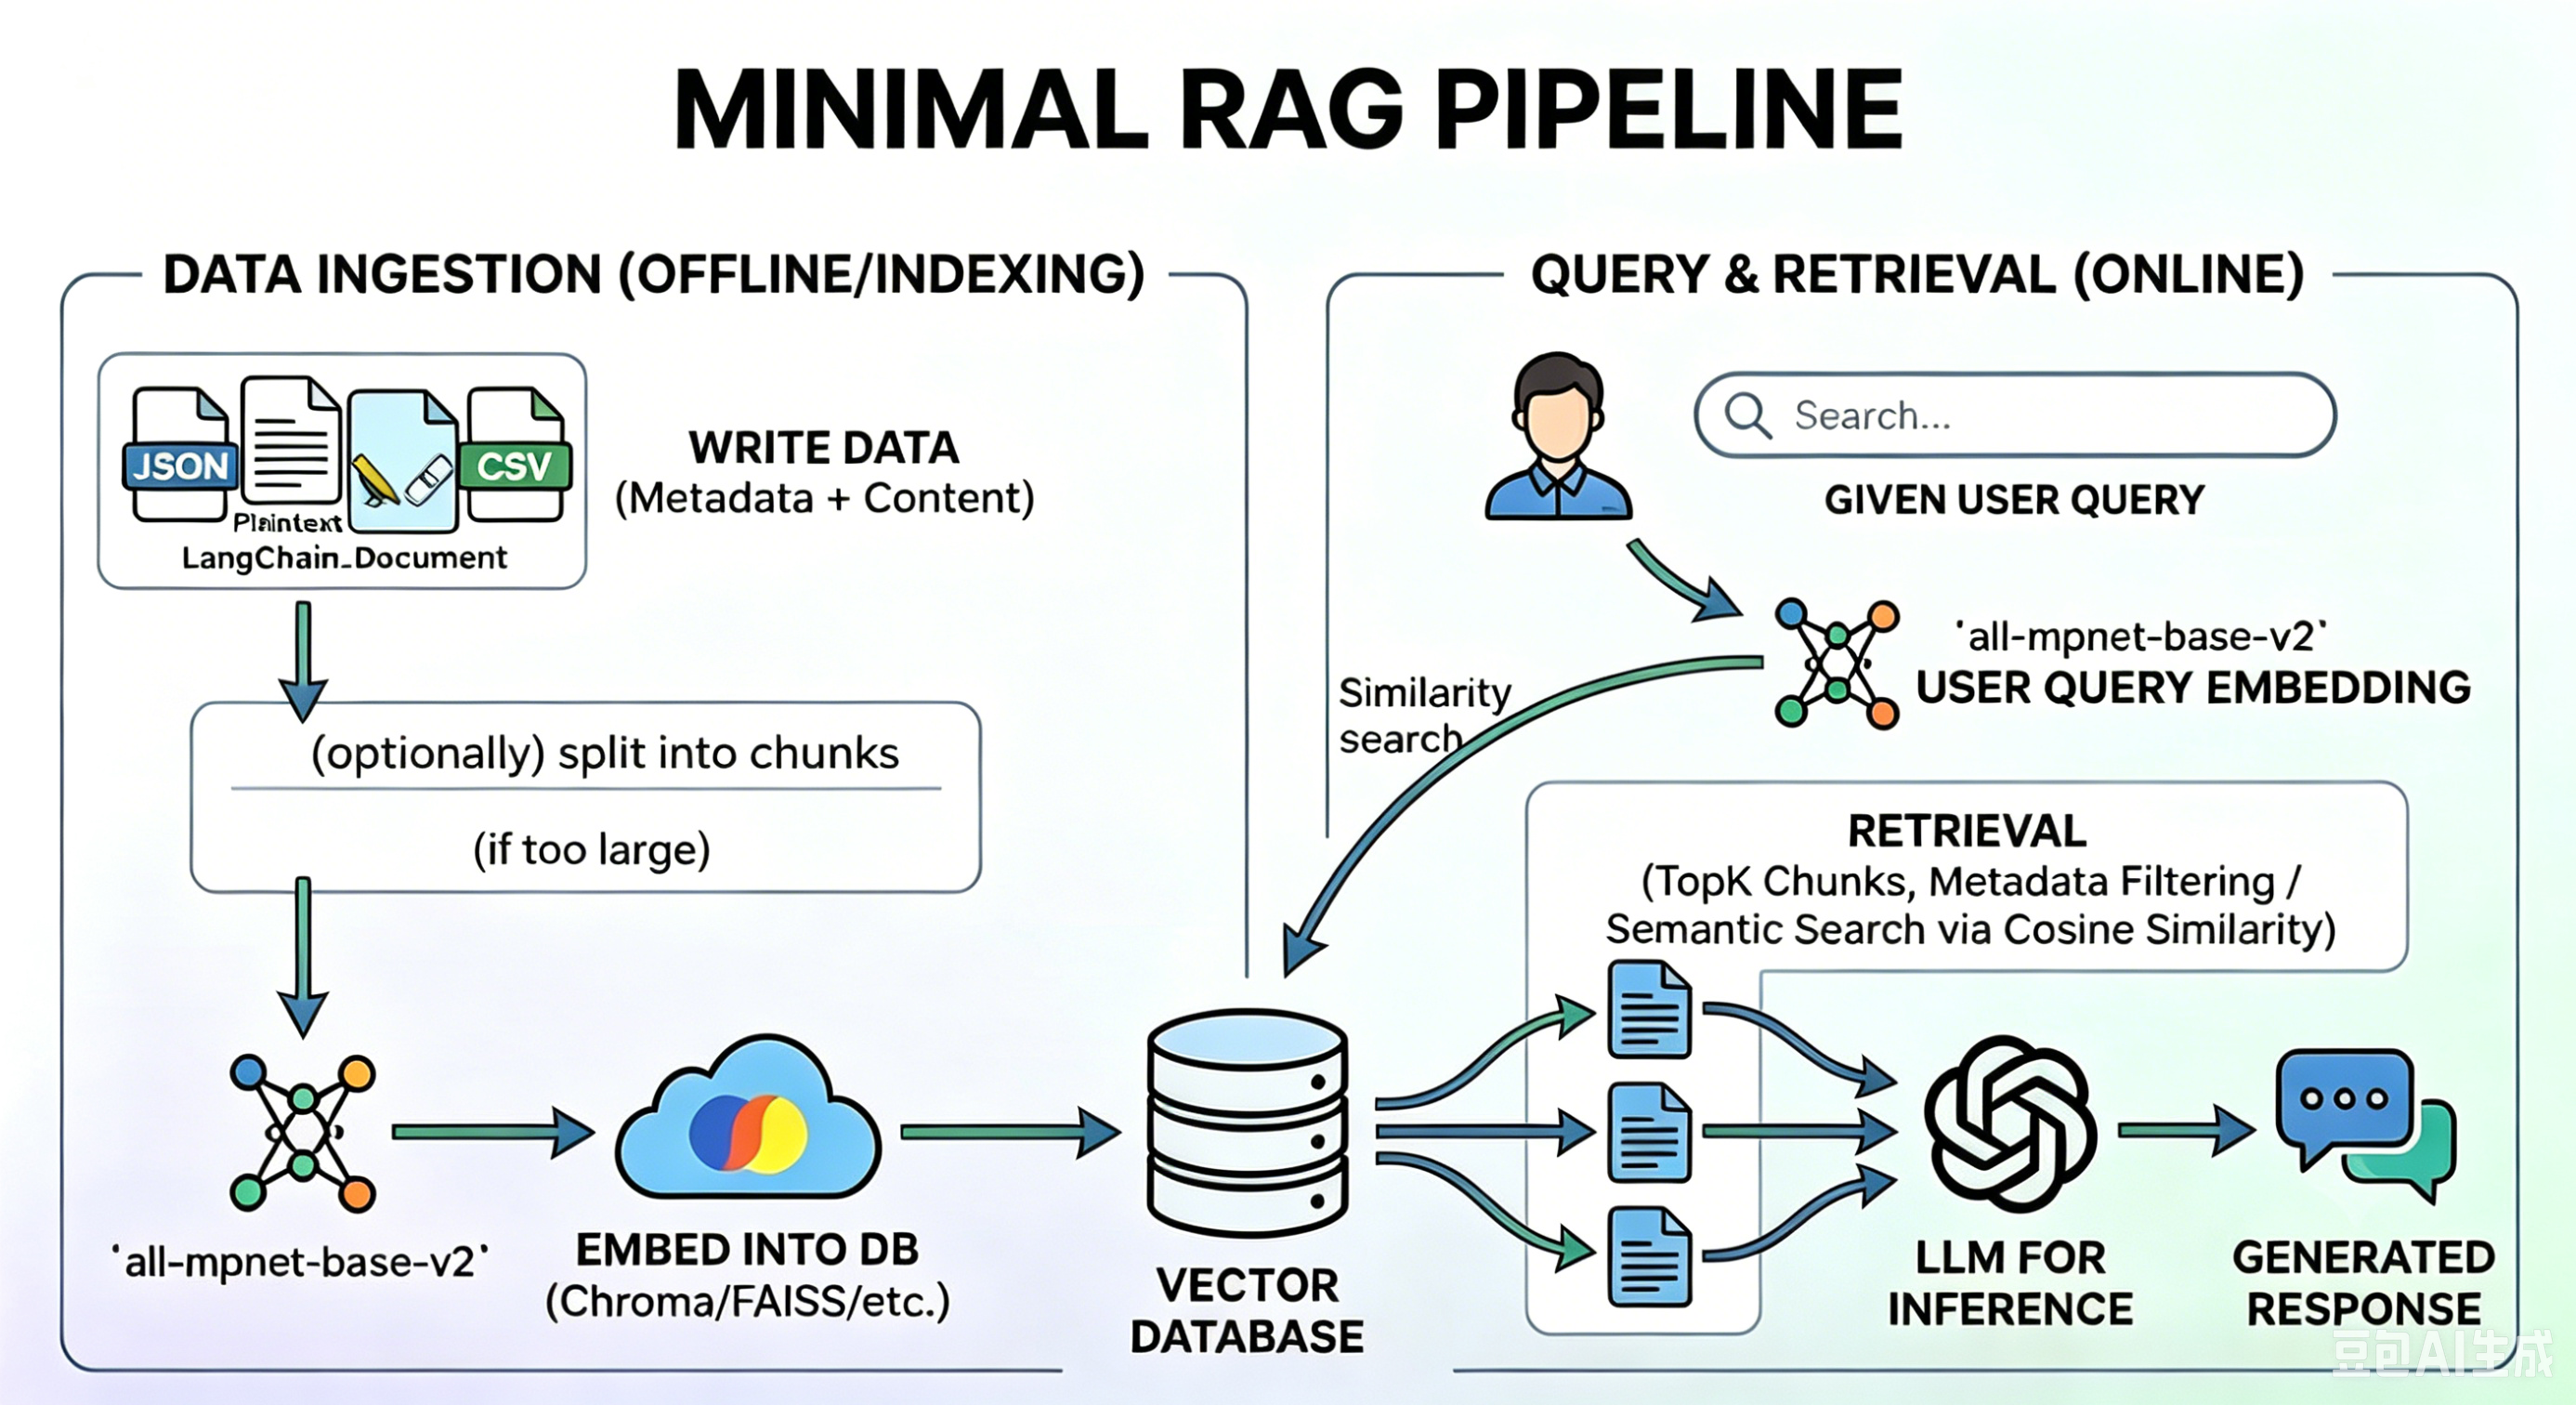